In [6]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
print ("enivorment ready!!!")

enivorment ready!!!


In [7]:
df=pd.read_csv("StudentsPerformance.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [9]:
df.dropna().sum

<bound method DataFrame.sum of      gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none     

In [10]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [11]:
df.isna().any()

gender                         False
race/ethnicity                 False
parental level of education    False
lunch                          False
test preparation course        False
math score                     False
reading score                  False
writing score                  False
dtype: bool

In [12]:
df.isnull().any()

gender                         False
race/ethnicity                 False
parental level of education    False
lunch                          False
test preparation course        False
math score                     False
reading score                  False
writing score                  False
dtype: bool

In [13]:
df[(df['math score']<0)&(df['reading score']<0)&(df['writing score']<0)]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score


In [14]:
avg_math=df['math score'].mean()
avg_reading=df['reading score'].mean()
avg_writing=df['writing score'].mean()

print("\n Average Math Score : ",avg_math)
print("\n Average reading Score : ",avg_reading)
print("\n Average writing Score : ",avg_writing)

averages={
    "Math Average":avg_math,
    "Reading Average":avg_reading,
    "Writing Average":avg_writing
}
print("\n",averages)


 Average Math Score :  66.089

 Average reading Score :  69.169

 Average writing Score :  68.054

 {'Math Average': np.float64(66.089), 'Reading Average': np.float64(69.169), 'Writing Average': np.float64(68.054)}


In [51]:
df['total_score']=df['math score']+df['reading score']+df['writing score']
rank_students=df.sort_values(
    by="total_score",
    ascending=False
    ).head(5)

rank_students

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
916,male,group E,bachelor's degree,standard,completed,100,100,100,300
962,female,group E,associate's degree,standard,none,100,100,100,300
458,female,group E,bachelor's degree,standard,none,100,100,100,300
114,female,group E,bachelor's degree,standard,completed,99,100,100,299
712,female,group D,some college,standard,none,98,100,99,297


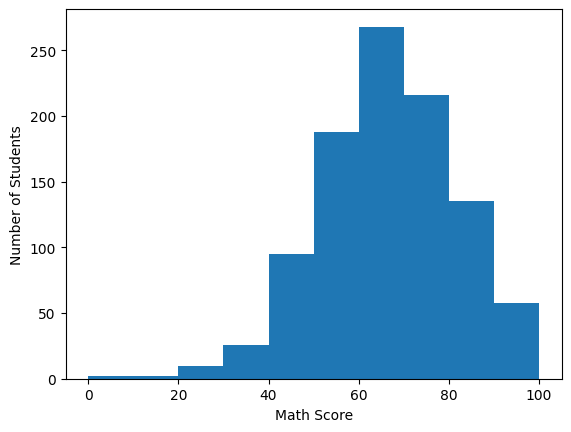

In [52]:
plt.hist(df['math score'])
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.show()

In [53]:
gender_avg=df.groupby('gender')[['math score','reading score','writing score']].mean()
gender_avg

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


Text(0, 0.5, 'Avergae Score')

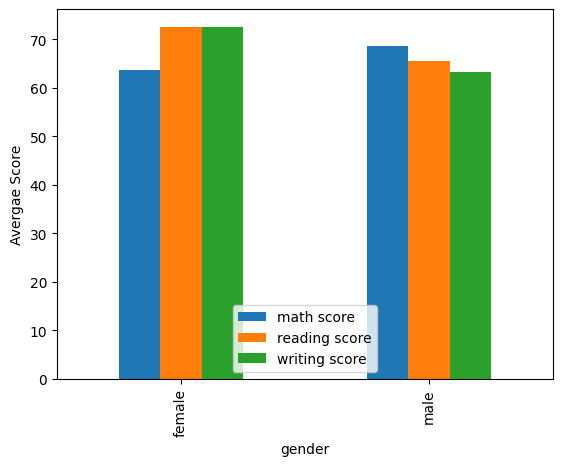

In [54]:
gender_avg.plot(kind='bar')

plt.ylabel('Avergae Score')

In [55]:
parent_avg=df.groupby('parental level of education')[['math score','reading score','writing score']].mean()
parent_avg

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


Text(0, 0.5, 'Avg scores')

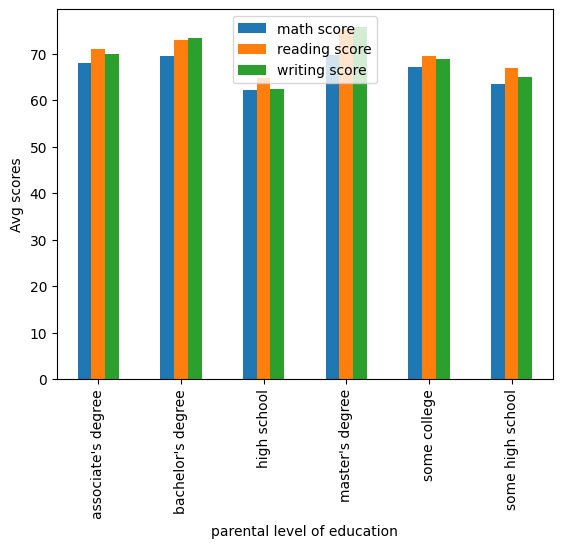

In [56]:
parent_avg.plot(kind='bar')
plt.ylabel('Avg scores')

In [57]:
race_avg=df.groupby('race/ethnicity')[['math score','reading score','writing score']].mean()
race_avg

,math score,reading score,writing score
race/ethnicity,,,
group A,61.629213,64.674157,62.674157
group B,63.452632,67.352632,65.600000
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143


<Axes: xlabel='race/ethnicity'>

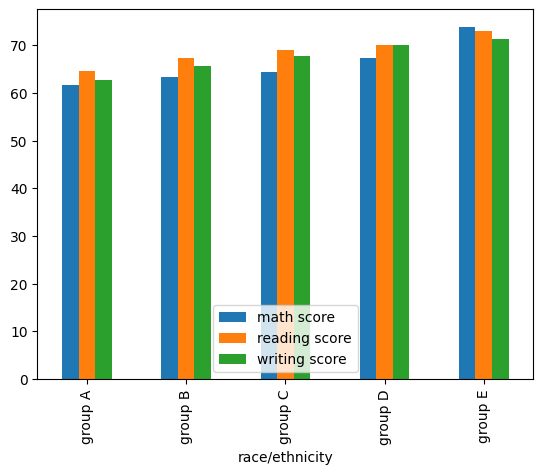

In [58]:
race_avg.plot(kind='bar')

Key Insights

1. Reading has the highest overall average score at **69.17**, followed by writing at **68.05** and mathematics at **66.09**.

2. Male students have a higher average mathematics score (**68.73**) than female students (**63.63**).

3. Female students perform better in reading and writing, with average scores of **72.61** and **72.47**, compared with **65.47** and **63.31** for male students.

4. Students whose parents have higher levels of education generally show stronger academic performance. Students with parents holding a master's degree have the highest average scores across all three subjects.

5. **Group E** has the highest average mathematics score at **73.82** and also records the highest average scores overall across the three subjects.

6. Group D is also a strong-performing group, with average scores of **67.36** in mathematics, **70.03** in reading, and **70.15** in writing.

7. The highest-performing students achieved exceptional results, with **three students obtaining a perfect total score of 300 out of 300**.

8. Group E is strongly represented among the highest-performing students, with **three of the first four students in the ranking belonging to Group E**.

9. Reading and writing scores are higher than mathematics scores on average, suggesting relatively stronger performance in language-related subjects.

10. The dataset contains **1,000 student records with no missing values detected**, making it suitable for further analysis without requiring missing-value treatment.
